**Protokół SMTP** - Simple Mail Transfer Protocol (Protokół Prostego Przesyłania Poczty), RFC 2821.
Protokół niezawodnego (gniazda TCP) przesyłania wiadomości tekstowych (e-mail) za pomocą prostych
komend tekstowych. W protokole SMTP komendy są ciągami znaków zakończonych znakiem niedrukowalnym
<CRLF> (czyli \r\n).

**Protokół ESMTP** - Extended SMTP (ESMTP) lub Enhanced SMTP jest rozszerzeniem protokołu SMTP
powstałym na skutek wielu jego ograniczeń (RFC 1869). Rozszerzenia te to głównie: nowe komendy SMTP:
EHLO, AUTH LOGIN oraz nowe parametry poleceń MAIL FROM i RCPT TO.

Komenda AUTH LOGIN to rozszerzenie protokołu Simple Mail Transfer Protocol o mechanizmy uwierzytelniania.
Każda z nich do komunikacji pomiędzy serwerem a klientem stosuje kodowanie Base64, które samo w sobie nie
zapewnia bezpieczeństwa danych. Uwierzytelnianie (ang. authentication) to proces polegający na potwierdzeniu
zadeklarowanej tożsamości podmiotu biorącego udział w procesie komunikacji. Celem uwierzytelniania jest
uzyskanie określonego poziomu pewności, że dany podmiot jest w rzeczywistości tym, za który się podaje.
Wprowadzenie tej usługi uniemożliwia wysyłania wiadomości z konta użytkownika przez osoby do tego
nieuprawnione. Osoba próbująca wysłać wiadomość jest proszona o podanie loginu i hasła do konta. Aby
skorzystać z autoryzacji, klient powinien zamiast standardowego powitania HELO użyć EHLO, które umożliwi
wykorzystanie rozszerzonego zestawu poleceń SMTP. W odpowiedzi serwer SMTP powinien zwrócić w
powitaniu ciąg znaków AUTH, a po nim dostępne metody uwierzytelniania. Opisany jest w RFC 2554.

***Przykładowy flow protokołu SMTP***:

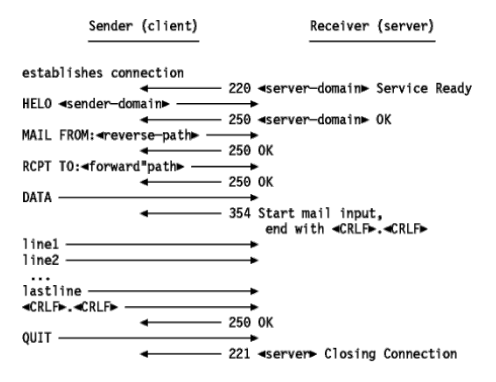

***Przykładowa komunikacja z serwerem ESMTP za pomocą klienta telnet***:
```
telnet interia.pl 587
Trying 217.74.65.23...
Connected to interia.pl.
Escape character is ’^]’.
220 ESMTP INTERIA.PL
EHLO nazwa_komputra
250-poczta.interia.pl
250-PIPELINING
250-SIZE 157286400
250-STARTTLS
250-AUTH PLAIN LOGIN
250-AUTH=PLAIN LOGIN
250-ENHANCEDSTATUSCODES
250 8BITMIME
AUTH LOGIN
334 VXNlcm5hbWU6
nazwa_uzytkownika_zakodowana_base64
334 UGFzc3dvcmQ6
haslo_zakodowane_base64
235 2.7.0 Authentication successful
MAIL FROM: <nadawca@gmail.com>
250 2.1.0 Ok
RCPT TO: <odbiorca@interia.pl>
250 2.1.5 Ok
DATA
354 End data with <CR><LF>.<CR><LF>
To: <odbiorca@interia.pl>
From: <nadawca@gmail.com>
Subject: Mozemy podac temat emaila
Tu wstawiamy tresc wiadomosci
.
250 OK. ID: 1488395c08fea12a
QUIT
221 2.0.0 Bye
Connection closed by foreign host.
```

**MIME** - (ang. Multipurpose Internet Mail Extensions) to standard stosowany przy przesyłaniu poczty
elektronicznej (ang. e-mail). MIME definiuje budowę komunikatu poczty elektronicznej. MIME, to inaczej
ielozadaniowe rozszerzenie poczty w Internecie, jest standardem pozwalającym przesyłać w sieci Internet
wszelkie dane (teksty, grafikę, zdjęcia, dźwięki, muzykę, programy) za pomocą standardowych narzędzi, takich
jak poczta, newsy czy WWW. Wbrew swojej nazwie (Mail Extension, czyli rozszerzenie poczty), zastosowanie
MIME nie ogranicza się wyłącznie do plików przesyłanych pocztą. Standard ten rozwinął się na tyle, że
wprowadzono go także do innych systemów przesyłania danych i obecnie jest to niekwestionowany standard we
wszystkich usługach Internetu, których podstawowym zadaniem jest przesyłanie tekstu.

Każda przesyłka pocztowa składa się z dwu zasadniczych częsci: nagłówków (coś na kształt „koperty”) i treści
przesyłki. Zawartość nagłówków szczegółowo określają następujące dokumenty: RFC822 i RFC1521. Nagłówki
oddzielone są od treści listu jedną linią pustą i określają, np.:
- From: adres nadawcy
- To: adres dobiorcy listu
- Subject: temat listu
- Cc: adres, na który została wysłana kopia listu

Przesyłki MIME zawierają dodatkowo nagłówek:
- Mime-Version: 1.0 który identyfikuje wszystkie takie przesyłki
- Content-Type: rodzaj zawartości przesyłki
- Content-Transfer-Encoding: sposób jej kodowania
- Content-Length: długość przesyłki (nie zawsze występuje)
- Content-description: opis zawartości przesyłki

Przykładowy nagłówek, Content-Type typu MIME wskazuje typ zawartości wiadomości. Składa się z typu
i podtypu. Jest dwuczęściowym identyfikatorem formatu plików w Internecie. Lista popularnych typów:
https://pl.wikipedia.org/wiki/Typ_MIME.

Przykład wysyłania e-maila z załącznikiem (plikiem tekstowym) z wykorzystaniem standardu MIME:

```
telnet interia.pl 587
Trying 217.74.65.23...
Connected to interia.pl.
Escape character is ’^]’.
220 ESMTP INTERIA.PL
HELO kasiula
250 poczta.interia.pl
AUTH LOGIN
334 VXNlcm5hbWU6
cGFzMjAxN0BpbnRlcmlhLnBs
334 UGFzc3dvcmQ6
UDRTSW5mMjAxNw==
235 2.7.0 Authentication successful
MAIL FROM: <pas2017@interia.pl>
250 2.1.0 Ok
RCPT TO: <pas2017@interia.pl>
RCPT TO: <katarzyna.mazur@gmail.com>
DATA250 2.1.5 Ok
250 2.1.5 Ok
354 End data with <CR><LF>.<CR><LF>
From: Nathaniel Borenstein <nsb@bellcore.com>
To: Ned Freed <ned@innosoft.com>
Subject: Sample message
MIME-Version: 1.0
Content-Type: multipart/mixed; boundary=sep
--sep
To
jest
tresc wiadomosci
--sep
Content-Type: text/x-log; name=\"text.log\"
Content-Disposition: attachment; filename=\"text.log\"
Content-Transfer-Encoding: base64
LyoKKiogc2VsZWN0c2VydmVyLmMgLS0gYSBjaGVlenkgbXVsdGlwZXJzb24gY2hh
dCBzZXJ2ZXIKKi8KCiNpbmNsdWRlIDxzdGRpby5oPgojaW5jbHVkZSA8c3RkbGli
Lmg+CiNpbmNsdWRlIDxzdHJpbmcuaD4KI2luY2x1ZGUgPHVuaXN0ZC5oPgojaW5j
bHVkZSA8c3lzL3R5cGVzLmg+CiNpbmNsdWRlIDxzeXMvc29ja2V0Lmg+CiNpbmNs
...
dCB3b3VsZCBuZXZlciBlbmQhCiAgICAKICAgIHJldHVybiAwOwp9Cgo=
--sep--
.
QUIT
```

**E-mail Spoofing** Informacje na temat wysyłającego email w e-mail (Pole „Od”) może być łatwo sfałszowana.
Jest to często stosowana technika przez spam by ukryć pochodzenie ich wiadomości e-mail co mogłoby
prowadzić do problemów takich jak błędne przekierowanie wiadomości po jej niedostarczeniu. E-mail adres
spoofing jest tworzone na podobnej zasadzie jak pisanie podrabianego powrotnego adresu korzystając z czasu
potrzebnego na dostarczenie wiadomości. Tak długo jak list pasuję do protokołu, (znaczki, kod pocztowy)
protokół SMTP wyśle wiadomość.
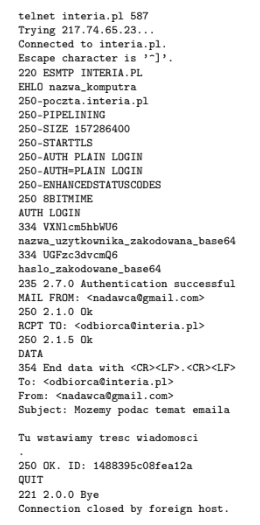
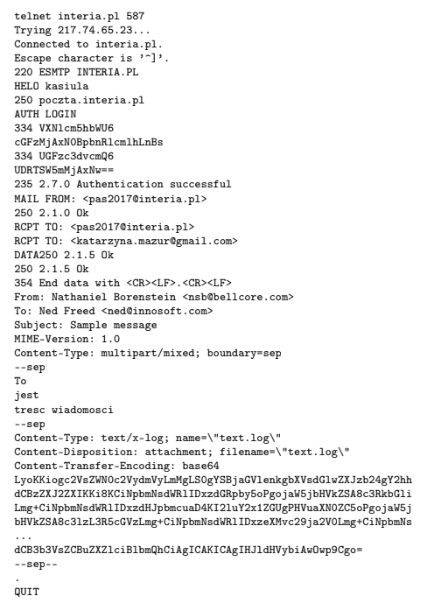

**Uwaga** W poniższych zadaniach zakładamy, iż serwer powinien obsługiwać tylko jednego klienta w danej chwili.

In [ ]:
import socket
import base64
import os
import sys

In [ ]:
SERVER = "127.0.0.1"
PORT = 2525
BOUNDARY = "----=_MimeBoundary_Python_Lab6"

# Mapowanie rozszerzeń na typy MIME
MIME_TYPES = {
    ".txt":  "text/plain",
    ".log":  "text/plain",
    ".csv":  "text/csv",
    ".html": "text/html",
    ".xml":  "text/xml",
    ".json": "application/json",
    ".pdf":  "application/pdf",
    ".png":  "image/png",
    ".jpg":  "image/jpeg",
    ".jpeg": "image/jpeg",
    ".gif":  "image/gif",
    ".bmp":  "image/bmp",
    ".webp": "image/webp",
    ".zip":  "application/zip",
}

In [ ]:
def get_mime_type(path: str) -> str:
    ext = os.path.splitext(path)[1].lower()
    return MIME_TYPES.get(ext, "application/octet-stream")


def file_to_base64_lines(path: str) -> list[str]:
    """Zwraca zawartość pliku zakodowaną Base64 jako listę linii (max 76 znaków)."""
    with open(path, "rb") as f:
        raw = f.read()
    encoded = base64.b64encode(raw).decode()
    return [encoded[i:i+76] for i in range(0, len(encoded), 76)]

In [ ]:
class SMTPTelnetClient:
    """Prosty klient SMTP na surowych gniazdach (jak telnet)."""

    def __init__(self, host: str, port: int):
        self.sock = socket.socket(socket.AF_INET, socket.SOCK_STREAM)
        self.sock.connect((host, port))
        print(f"[Połączono z {host}:{port}]")

    def recv(self) -> str:
        buf = b""
        while True:
            chunk = self.sock.recv(4096)
            if not chunk:
                break
            buf += chunk
            # Odpowiedź SMTP może być wieloliniowa (np. 250-xxx\r\n250 xxx\r\n)
            # Kończymy gdy ostatnia linia to "NNN " (bez myślnika)
            lines = buf.decode(errors="replace").splitlines()
            if lines:
                last = lines[-1]
                if len(last) >= 4 and last[3] == " ":
                    break
                if len(last) < 4:
                    break
        response = buf.decode(errors="replace")
        print(f"S: {response.strip()}")
        return response

    def send(self, cmd: str):
        print(f"C: {cmd}")
        self.sock.sendall((cmd + "\r\n").encode())

    def quit(self):
        self.send("QUIT")
        self.recv()
        self.sock.close()
        print("[Rozłączono]")


def encode_b64(text: str) -> str:
    return base64.b64encode(text.encode()).decode()

In [ ]:
class SMTPClient:
    def __init__(self, host, port):
        self.sock = socket.socket(socket.AF_INET, socket.SOCK_STREAM)
        self.sock.connect((host, port))
        print(f"[Połączono z {host}:{port}]")

    def recv(self) -> str:
        buf = b""
        while True:
            chunk = self.sock.recv(4096)
            if not chunk:
                break
            buf += chunk
            lines = buf.decode(errors="replace").splitlines()
            if lines and len(lines[-1]) >= 4 and lines[-1][3] == " ":
                break
            if lines and len(lines[-1]) < 4:
                break
        resp = buf.decode(errors="replace")
        print(f"S: {resp.strip()}")
        return resp

    def send(self, cmd: str):
        print(f"C: {cmd}")
        self.sock.sendall((cmd + "\r\n").encode())

    def send_raw(self, data: bytes):
        """Wysyła surowe bajty (np. base64 załącznika)."""
        self.sock.sendall(data + b"\r\n")

    def login(self, user: str, password: str):
        self.recv()  # powitanie
        self.send("EHLO mojkomp")
        self.recv()
        self.send("AUTH LOGIN")
        self.recv()
        self.send(base64.b64encode(user.encode()).decode())
        self.recv()
        self.send(base64.b64encode(password.encode()).decode())
        self.recv()

    def quit(self):
        self.send("QUIT")
        self.recv()
        self.sock.close()
        print("[Rozłączono]")


def file_to_base64(path: str) -> str:
    """Koduje plik do base64 w liniach po 76 znaków (standard MIME)."""
    with open(path, "rb") as f:
        raw = f.read()
    encoded = base64.b64encode(raw).decode()
    # Dzielimy na linie po 76 znaków
    lines = [encoded[i:i+76] for i in range(0, len(encoded), 76)]
    return "\n".join(lines)


def create_sample_text_file(path: str):
    """Tworzy przykładowy plik tekstowy do załączenia."""
    with open(path, "w", encoding="utf-8") as f:
        f.write("# Przykładowy plik tekstowy\n\n")
        f.write("Laboratorium 6 - Programowanie Aplikacji Sieciowych\n")
        f.write("Protokół SMTP / ESMTP\n\n")
        f.write("Ten plik jest załącznikiem w formacie MIME.\n")
        f.write("Zakodowano go w Base64 przed wysłaniem.\n\n")
        f.write("Funkcje MIME:\n")
        f.write("- multipart/mixed - wiele części wiadomości\n")
        f.write("- Content-Type - typ zawartości\n")
        f.write("- Content-Transfer-Encoding: base64\n")
        f.write("- Content-Disposition: attachment\n")
    print(f"[Utworzono plik: {path}]")


def create_sample_png(path: str):
    """Tworzy minimalny prawidłowy plik PNG (czerwony kwadrat 10x10)."""
    import struct, zlib

    def make_png():
        # Nagłówek PNG
        sig = b'\x89PNG\r\n\x1a\n'

        # Chunk IHDR
        width, height = 10, 10
        ihdr_data = struct.pack('>IIBBBBB', width, height, 8, 2, 0, 0, 0)
        ihdr = make_chunk(b'IHDR', ihdr_data)

        # Chunk IDAT - dane obrazu (czerwony kolor RGB)
        raw_rows = b''
        for _ in range(height):
            row = b'\x00'  # filter type None
            for _ in range(width):
                row += b'\xff\x00\x00'  # R=255, G=0, B=0
            raw_rows += row
        compressed = zlib.compress(raw_rows)
        idat = make_chunk(b'IDAT', compressed)

        # Chunk IEND
        iend = make_chunk(b'IEND', b'')

        return sig + ihdr + idat + iend

    def make_chunk(chunk_type: bytes, data: bytes) -> bytes:
        c = chunk_type + data
        return struct.pack('>I', len(data)) + c + struct.pack('>I', zlib.crc32(c) & 0xffffffff)

    with open(path, 'wb') as f:
        f.write(make_png())
    print(f"[Utworzono plik PNG: {path}]")

def ask_recipients() -> list[str]:
    """Pyta o adresy odbiorców (jeden lub kilka)."""
    recipients = []
    print("Podaj adres(y) odbiorcy (Enter bez wartosci - koniec):")
    while True:
        r = input(f"  Odbiorca {len(recipients)+1}: ").strip()
        if not r:
            if not recipients:
                print("  Musisz podac co najmniej jednego odbiorcę!")
                continue
            break
        recipients.append(r)
    return recipients


def ask_body() -> str:
    """Pyta o treść wiadomości (wiele linii, Enter x2 = koniec)."""
    print("Podaj tresc wiadomosci (dwa razy Enter aby zakonczyc):")
    lines = []
    empty_count = 0
    while True:
        line = input()
        if line == "":
            empty_count += 1
            if empty_count >= 2:
                break
            lines.append("")
        else:
            empty_count = 0
            lines.append(line)
    return "\n".join(lines).rstrip()

def send_email_with_attachment(attachment_path: str, attachment_type: str):
    """
    Główna funkcja wysyłania e-maila z załącznikiem.
    attachment_type: 'text' lub 'image'
    """
    print("\n" + "=" * 60)
    if attachment_type == "text":
        print("  Zadanie 7 - Klient SMTP z załącznikiem tekstowym")
    else:
        print("  Zadanie 8 - Klient SMTP z załącznikiem obrazkowym")
    print("=" * 60)
    print()

    # Dane użytkownika
    sender = input("Adres nadawcy (Enter = pas2017@interia.pl): ").strip()
    if not sender:
        sender = "pas2017@interia.pl"

    recipients = ask_recipients()
    subject = input("Temat: ").strip()
    body = ask_body()

    print("\nDane logowania:")
    login_user = input("  Login (Enter = pas2017@interia.pl): ").strip() or "pas2017@interia.pl"
    login_pass = input("  Haslo (Enter = P4SInf2017): ").strip() or "P4SInf2017"

    if not os.path.exists(attachment_path):
        print(f"[BŁĄD] Plik '{attachment_path}' nie istnieje!")
        return

    mime_type = get_mime_type(attachment_path)
    filename = os.path.basename(attachment_path)
    b64_lines = file_to_base64_lines(attachment_path)

    print(f"\n[Załącznik: {filename} | typ MIME: {mime_type} | rozmiar b64: {sum(len(l) for l in b64_lines)} znaków]")
    print(f"[Łączę z {SERVER}:{PORT}...]")

    try:
        c = SMTPClient(SERVER, PORT)
    except ConnectionRefusedError:
        print(f"[BŁĄD] Nie można połączyć z {SERVER}:{PORT}. Uruchom smtp_server.py!")
        return

    print("\n--- Sesja SMTP ---")
    c.recv()  # 220

    c.send("EHLO klient_zadania_7_8")
    c.recv()

    c.send("AUTH LOGIN")
    c.recv()
    c.send(base64.b64encode(login_user.encode()).decode())
    c.recv()
    c.send(base64.b64encode(login_pass.encode()).decode())
    resp = c.recv()

    if not resp.startswith("235"):
        print("[BŁĄD] Uwierzytelnienie nieudane!")
        c.quit()
        return

    c.send(f"MAIL FROM: <{sender}>")
    c.recv()

    for r in recipients:
        c.send(f"RCPT TO: <{r}>")
        c.recv()

    c.send("DATA")
    c.recv()

    # ── Nagłówki MIME ──────────────────────────────────────────────
    c.send(f"From: <{sender}>")
    c.send(f"To: {', '.join(f'<{r}>' for r in recipients)}")
    c.send(f"Subject: {subject}")
    c.send("MIME-Version: 1.0")
    c.send(f'Content-Type: multipart/mixed; boundary="{BOUNDARY}"')
    c.send("")

    # ── Część 1: treść tekstowa ────────────────────────────────────
    c.send(f"--{BOUNDARY}")
    c.send("Content-Type: text/plain; charset=utf-8")
    c.send("Content-Transfer-Encoding: 8bit")
    c.send("")
    for line in body.splitlines():
        c.send(line)
    c.send("")

    # ── Część 2: załącznik ─────────────────────────────────────────
    c.send(f"--{BOUNDARY}")
    c.send(f'Content-Type: {mime_type}; name="{filename}"')
    c.send(f'Content-Disposition: attachment; filename="{filename}"')
    c.send("Content-Transfer-Encoding: base64")
    c.send("")
    for line in b64_lines:
        c.send(line)
    c.send("")

    c.send(f"--{BOUNDARY}--")
    c.send(".")
    c.recv()

    c.quit()
    print(f"\n[OK] Wiadomość z załącznikiem '{filename}' wysłana!")

In [ ]:
def build_html_body(subject: str, plain_text: str) -> str:
    """
    Buduje treść HTML z formatowaniem na podstawie tekstu zwykłego.
    Używa tagów: <b>, <i>, <u>, <h1>-<h3>, <p>, <ul>, <li>, <a>, <br>, kolory CSS.
    """
    html = f"""<!DOCTYPE html>
<html lang="pl">
<head>
  <meta charset="utf-8">
  <meta name="viewport" content="width=device-width">
  <title>{subject}</title>
  <style>
    body {{
      font-family: Arial, sans-serif;
      font-size: 14px;
      color: #222;
      background: #f9f9f9;
      padding: 20px;
    }}
    .container {{
      background: #ffffff;
      border: 1px solid #ddd;
      border-radius: 6px;
      padding: 24px;
      max-width: 600px;
    }}
    h1 {{ color: #1a5276; }}
    h2 {{ color: #1f618d; }}
    h3 {{ color: #2471a3; }}
    .highlight {{ background-color: #fef9e7; padding: 2px 4px; border-radius: 3px; }}
    .footer {{ margin-top: 24px; font-size: 12px; color: #888; border-top: 1px solid #eee; padding-top: 10px; }}
    ul {{ padding-left: 20px; }}
    li {{ margin: 4px 0; }}
    a {{ color: #2980b9; }}
  </style>
</head>
<body>
<div class="container">

  <h1>&#128231; {subject}</h1>

  <p>
    Oto przykładowa wiadomość z <b>pogrubionym</b>, <i>pochylonym (kursywa)</i>
    oraz <u>podkreślonym</u> tekstem.
  </p>

  <h2>Tresc wiadomosci</h2>
  <p>
"""
    # Zamieniamy zwykły tekst na paragrafy HTML
    for line in plain_text.splitlines():
        line_stripped = line.strip()
        if line_stripped:
            html += f"    {line_stripped}<br>\n"

    html += """  </p>

  <h3>Przykladowe formatowanie HTML w e-mailu</h3>
  <ul>
    <li><b>Pogrubienie</b> &mdash; tag <code>&lt;b&gt;</code></li>
    <li><i>Pochylenie</i> &mdash; tag <code>&lt;i&gt;</code></li>
    <li><u>Podkreslenie</u> &mdash; tag <code>&lt;u&gt;</code></li>
    <li><span style="color: #e74c3c;">Czerwony tekst</span> &mdash; <code>style="color: red"</code></li>
    <li><span style="color: #27ae60;">Zielony tekst</span> &mdash; <code>style="color: green"</code></li>
    <li><span class="highlight">Wyroznienie tlem</span> &mdash; CSS background-color</li>
    <li><a href="https://www.ietf.org/rfc/rfc2821.txt">RFC 2821 - SMTP</a> &mdash; tag <code>&lt;a&gt;</code></li>
  </ul>

  <p>
    <b>Laboratorium 6</b> - Programowanie Aplikacji Sieciowych<br>
    Protokol <i>ESMTP</i> z formatowaniem <u>MIME HTML</u>
  </p>

  <div class="footer">
    Wiadomosc wyslana przez klienta SMTP napisanego w Python (zadanie 9).
  </div>

</div>
</body>
</html>"""
    return html

1. Wykorzystując protokół telnet, oraz serwer ESMTP działający pod adresem interia.pl na porcie 587
wyślij wiadomość e-mail używając komend protokołu ESMTP.

In [ ]:
def zadanie1():
    print("\n" + "=" * 60)
    print("ZADANIE 1 - Wysłanie e-maila przez ESMTP (AUTH LOGIN)")
    print("=" * 60)

    c = SMTPTelnetClient(SERVER, PORT)
    c.recv()  # 220 powitanie

    c.send("EHLO mojkomp")
    c.recv()

    c.send("AUTH LOGIN")
    c.recv()  # 334 Username:

    c.send(encode_b64("pas2017@interia.pl"))
    c.recv()  # 334 Password:

    c.send(encode_b64("P4SInf2017"))
    c.recv()  # 235 OK

    c.send("MAIL FROM: <pas2017@interia.pl>")
    c.recv()

    c.send("RCPT TO: <pasinf2017@interia.pl>")
    c.recv()

    c.send("DATA")
    c.recv()  # 354

    c.send("From: <pas2017@interia.pl>")
    c.send("To: <pasinf2017@interia.pl>")
    c.send("Subject: Zadanie 1 - Testowy e-mail")
    c.send("")
    c.send("Czesc! To jest testowy e-mail z Zadania 1.")
    c.send("Wysłany przez protokół ESMTP w Pythonie.")
    c.send(".")
    c.recv()  # 250 OK

    c.quit()
    print(">>> Zadanie 1 zakonczone <<<\n")

In [ ]:
zadanie1()

2. Wykorzystując protokół telnet, oraz serwer ESMTP działający pod adresem interia.pl na porcie 587
wyślij wiadomość e-mail do kilku odbiorców używając komend protokołu ESMTP.

In [ ]:
def zadanie2():
    print("\n" + "=" * 60)
    print("ZADANIE 2 - Wysłanie e-maila do kilku odbiorców")
    print("=" * 60)

    c = SMTPTelnetClient(SERVER, PORT)
    c.recv()

    c.send("EHLO mojkomp")
    c.recv()

    c.send("AUTH LOGIN")
    c.recv()
    c.send(encode_b64("pas2017@interia.pl"))
    c.recv()
    c.send(encode_b64("P4SInf2017"))
    c.recv()

    c.send("MAIL FROM: <pas2017@interia.pl>")
    c.recv()

    # Wielu odbiorców - kilka komend RCPT TO
    recipients = [
        "pasinf2017@interia.pl",
        "odbiorca2@localhost",
        "odbiorca3@localhost",
    ]
    for r in recipients:
        c.send(f"RCPT TO: <{r}>")
        c.recv()

    c.send("DATA")
    c.recv()

    c.send("From: <pas2017@interia.pl>")
    c.send(f"To: {', '.join(f'<{r}>' for r in recipients)}")
    c.send("Subject: Zadanie 2 - Wiadomosc do wielu odbiorców")
    c.send("")
    c.send("Ta wiadomosc zostala wyslana do kilku odbiorcow naraz.")
    c.send(f"Odbiorcy: {', '.join(recipients)}")
    c.send(".")
    c.recv()

    c.quit()
    print(">>> Zadanie 2 zakonczone <<<\n")

In [ ]:
zadanie2()

3. Wykorzystując protokół telnet, oraz serwer ESMTP działający pod adresem interia.pl na porcie 587
wyślij wiadomość spoofed email (z podmienionym adresem nadawcy) używając komend protokołu ESMTP.

In [ ]:
def zadanie3():
    print("\n" + "=" * 60)
    print("ZADANIE 3 - E-mail Spoofing (fałszywy adres nadawcy)")
    print("=" * 60)

    c = SMTPTelnetClient(SERVER, PORT)
    c.recv()

    # Używamy HELO zamiast EHLO (bez AUTH - klasyczny SMTP)
    c.send("HELO mojkomp")
    c.recv()

    # MAIL FROM z podrobionym adresem (np. prezydent@gov.pl)
    spoofed_sender = "prezydent@gov.pl"
    c.send(f"MAIL FROM: <{spoofed_sender}>")
    c.recv()

    c.send("RCPT TO: <pasinf2017@interia.pl>")
    c.recv()

    c.send("DATA")
    c.recv()

    # W nagłówku też podajemy fałszywy adres
    c.send(f"From: Prezydent RP <{spoofed_sender}>")
    c.send("To: <pasinf2017@interia.pl>")
    c.send("Subject: Zadanie 3 - Spoofed Email (DEMO)")
    c.send("")
    c.send("UWAGA: To jest demonstracja e-mail spoofingu!")
    c.send(f"Adres nadawcy '{spoofed_sender}' jest sfałszowany.")
    c.send("Pole MAIL FROM i naglowek From mozna latwo podrobić")
    c.send("nie mając dostępu do konta nadawcy.")
    c.send(".")
    c.recv()

    c.quit()
    print(">>> Zadanie 3 zakonczone <<<\n")
    print("UWAGA EDUKACYJNA: Spoofing jest możliwy, bo protokół SMTP")
    print("nie weryfikuje tożsamości nadawcy bez dodatkowych mechanizmów")
    print("(SPF, DKIM, DMARC).\n")

In [ ]:
zadanie3()

4. Wykorzystując protokół telnet, oraz serwer ESMTP działający pod adresem interia.pl na porcie 587 wyślij wiadomość e-mail używając komend protokołu ESMTP. Do wiadomości dodaj załącznik - dowolny plik tekstowy (sprawdź format MIME: Multipart i Content-Type). Możesz wykorzystać openssl do przekonwertowania pliku: cat plik |openssl base64.

In [ ]:
def zadanie4():
    print("\n" + "=" * 60)
    print("ZADANIE 4 - E-mail z załącznikiem tekstowym (MIME)")
    print("=" * 60)

    txt_path = "zalacznik.txt"
    if not os.path.exists(txt_path):
        create_sample_text_file(txt_path)

    b64_content = file_to_base64(txt_path)

    c = SMTPClient(SERVER, PORT)
    c.login("pas2017@interia.pl", "P4SInf2017")

    c.send("MAIL FROM: <pas2017@interia.pl>")
    c.recv()
    c.send("RCPT TO: <pasinf2017@interia.pl>")
    c.recv()
    c.send("DATA")
    c.recv()

    # Nagłówki MIME
    c.send("From: <pas2017@interia.pl>")
    c.send("To: <pasinf2017@interia.pl>")
    c.send("Subject: Zadanie 4 - E-mail z zalacznikiem tekstowym")
    c.send("MIME-Version: 1.0")
    c.send(f'Content-Type: multipart/mixed; boundary="{BOUNDARY}"')
    c.send("")

    # Część 1: treść wiadomości (plain text)
    c.send(f"--{BOUNDARY}")
    c.send("Content-Type: text/plain; charset=utf-8")
    c.send("Content-Transfer-Encoding: 8bit")
    c.send("")
    c.send("Czesc!")
    c.send("W zalaczeniu przesylam plik tekstowy zakodowany w Base64.")
    c.send("To jest demonstracja formatu MIME multipart/mixed.")
    c.send("")

    # Część 2: załącznik tekstowy
    c.send(f"--{BOUNDARY}")
    c.send(f'Content-Type: text/plain; name="{txt_path}"')
    c.send(f'Content-Disposition: attachment; filename="{txt_path}"')
    c.send("Content-Transfer-Encoding: base64")
    c.send("")
    # Wysyłamy zakodowany plik linia po linii
    for line in b64_content.splitlines():
        c.send(line)
    c.send("")

    # Zamknięcie granicy MIME
    c.send(f"--{BOUNDARY}--")
    c.send(".")
    c.recv()

    c.quit()
    print(">>> Zadanie 4 zakonczone <<<\n")

In [ ]:
zadanie4()

5. Wykorzystując protokół telnet, oraz serwer ESMTP działający pod adresem interia.pl na porcie 587 wyślij wiadomość e-mail używając komend protokołu ESMTP. Do wiadomości dodaj załącznik - dowolny obrazek (sprawdź format MIME: Multipart i Content-Type). Możesz wykorzystać openssl do przekonwertowania obrazka: cat obrazek |openssl base64.

In [ ]:
def zadanie5():
    print("\n" + "=" * 60)
    print("ZADANIE 5 - E-mail z załącznikiem obrazkowym (MIME)")
    print("=" * 60)

    img_path = "obrazek.png"
    if not os.path.exists(img_path):
        create_sample_png(img_path)

    b64_content = file_to_base64(img_path)

    c = SMTPClient(SERVER, PORT)
    c.login("pas2017@interia.pl", "P4SInf2017")

    c.send("MAIL FROM: <pas2017@interia.pl>")
    c.recv()
    c.send("RCPT TO: <pasinf2017@interia.pl>")
    c.recv()
    c.send("DATA")
    c.recv()

    # Nagłówki
    c.send("From: <pas2017@interia.pl>")
    c.send("To: <pasinf2017@interia.pl>")
    c.send("Subject: Zadanie 5 - E-mail z zalacznikiem obrazkowym")
    c.send("MIME-Version: 1.0")
    c.send(f'Content-Type: multipart/mixed; boundary="{BOUNDARY}"')
    c.send("")

    # Część 1: treść
    c.send(f"--{BOUNDARY}")
    c.send("Content-Type: text/plain; charset=utf-8")
    c.send("Content-Transfer-Encoding: 8bit")
    c.send("")
    c.send("Czesc!")
    c.send("W zalaczeniu przesylam obrazek PNG zakodowany w Base64.")
    c.send("Content-Type dla obrazkow PNG to: image/png")
    c.send("")

    # Część 2: załącznik PNG
    c.send(f"--{BOUNDARY}")
    c.send(f'Content-Type: image/png; name="{img_path}"')
    c.send(f'Content-Disposition: attachment; filename="{img_path}"')
    c.send("Content-Transfer-Encoding: base64")
    c.send("")
    for line in b64_content.splitlines():
        c.send(line)
    c.send("")

    c.send(f"--{BOUNDARY}--")
    c.send(".")
    c.recv()

    c.quit()
    print(">>> Zadanie 5 zakonczone <<<\n")

In [ ]:
zadanie5()

6. Napisz program klienta, który połączy się z serwerem ESMTP działającym pod adresem interia.pl na porcie 587, a następnie wyśle wiadomość e-mail używając komend protokołu ESMTP. O adres nadawcy, odbiorcy (odbiorców), temat wiadomości i jej treść zapytaj użytkownika.

In [ ]:
def zadanie6():
    print("=" * 60)
    print("  Zadanie 6 - Interaktywny klient SMTP")
    print("=" * 60)
    print()

    # Zbieramy dane od użytkownika
    sender = input("Adres nadawcy: ").strip()
    if not sender:
        sender = "pas2017@interia.pl"

    recipients = ask_recipients()
    subject = input("Temat: ").strip()
    body = ask_body()

    # Dane uwierzytelniające
    print("\nDane logowania do serwera SMTP:")
    login_user = input("  Login (Enter = pas2017@interia.pl): ").strip()
    if not login_user:
        login_user = "pas2017@interia.pl"
    login_pass = input("  Haslo (Enter = P4SInf2017): ").strip()
    if not login_pass:
        login_pass = "P4SInf2017"

    print(f"\n[Łączę z serwerem {SERVER}:{PORT}...]")
    try:
        c = SMTPClient(SERVER, PORT)
    except ConnectionRefusedError:
        print(f"[BŁĄD] Nie można połączyć z {SERVER}:{PORT}")
        print("Uruchom najpierw smtp_server.py!")
        return

    print("\n--- Sesja SMTP ---")
    c.recv()  # 220 powitanie

    c.send("EHLO klient_zadanie6")
    c.recv()

    # Uwierzytelnienie
    c.send("AUTH LOGIN")
    c.recv()  # 334 Username:
    c.send(base64.b64encode(login_user.encode()).decode())
    c.recv()  # 334 Password:
    c.send(base64.b64encode(login_pass.encode()).decode())
    resp = c.recv()  # 235 OK lub 535 błąd

    if not resp.startswith("235"):
        print("\n[BŁĄD] Uwierzytelnienie nieudane!")
        c.quit()
        return

    c.send(f"MAIL FROM: <{sender}>")
    c.recv()

    for r in recipients:
        c.send(f"RCPT TO: <{r}>")
        c.recv()

    c.send("DATA")
    c.recv()

    # Nagłówki i treść
    c.send(f"From: <{sender}>")
    c.send(f"To: {', '.join(f'<{r}>' for r in recipients)}")
    c.send(f"Subject: {subject}")
    c.send("Content-Type: text/plain; charset=utf-8")
    c.send("")
    for line in body.splitlines():
        # byte-stuffing: linie zaczynające się od '.' zamieniamy na '..'
        if line.startswith("."):
            line = "." + line
        c.send(line)
    c.send(".")
    c.recv()

    c.quit()
    print("\n[OK] Wiadomość wysłana pomyślnie!")

In [ ]:
zadanie6()

7. Napisz program klienta, który połączy się z serwerem ESMTP działającym pod adresem interia.pl na porcie 587, a następnie wyśle wiadomość e-mail używając komend protokołu ESMTP. Do wiadomości dodaj załącznik - dowolny plik tekstowy (sprawdź format MIME: Multipart i Content-Type). Nie wykorzystuj gotowych bibliotek. O adres nadawcy, odbiorcy (odbiorców), temat wiadomości i jej treść zapytaj użytkownika.

**Note:** W pliku ```zadanie_7_8.py```

8. Napisz program klienta, który połączy się z serwerem ESMTP działającym pod adresem interia.pl na porcie 587, a następnie wyśle wiadomość e-mail używając komend protokołu ESMTP. Do wiadomości dodaj załącznik - dowolny obrazek (sprawdź format MIME: Multipart i Content-Type). Nie wykorzystuj gotowych bibliotek. O adres nadawcy, odbiorcy (odbiorców), temat wiadomości i jej treść zapytaj użytkownika.

**Note:** W pliku ```zadanie_7_8.py```

9. Napisz program klienta, który połączy się z serwerem ESMTP działającym pod adresem interia.pl na porcie 587, a następnie wyśle wiadomość e-mail używając komend protokołu ESMTP. Treść wiadomości powinna zostać sformatowana za pomocą tagów HTML, przykładowo: \<b>pogrubienie\</b>, \<i>pochylenie\</i>, \<u>podkreślenie\</u> i innych wybranych.

In [ ]:
def zadanie9():
    print("=" * 60)
    print("  Zadanie 9 - Klient SMTP z treścią HTML")
    print("=" * 60)
    print()

    sender = input("Adres nadawcy (Enter = pas2017@interia.pl): ").strip() or "pas2017@interia.pl"
    recipients = ask_recipients()
    subject = input("Temat: ").strip() or "Wiadomosc HTML - Zadanie 9"
    plain_text = ask_body()

    print("\nDane logowania:")
    login_user = input("  Login (Enter = pas2017@interia.pl): ").strip() or "pas2017@interia.pl"
    login_pass = input("  Haslo (Enter = P4SInf2017): ").strip() or "P4SInf2017"

    html_body = build_html_body(subject, plain_text)

    print(f"\n[Łączę z {SERVER}:{PORT}...]")
    try:
        c = SMTPClient(SERVER, PORT)
    except ConnectionRefusedError:
        print(f"[BŁĄD] Nie można połączyć z {SERVER}:{PORT}. Uruchom smtp_server.py!")
        return

    print("\n--- Sesja SMTP ---")
    c.recv()  # 220

    c.send("EHLO klient_zadanie9_html")
    c.recv()

    c.send("AUTH LOGIN")
    c.recv()
    c.send(base64.b64encode(login_user.encode()).decode())
    c.recv()
    c.send(base64.b64encode(login_pass.encode()).decode())
    resp = c.recv()

    if not resp.startswith("235"):
        print("[BŁĄD] Uwierzytelnienie nieudane!")
        c.quit()
        return

    c.send(f"MAIL FROM: <{sender}>")
    c.recv()
    for r in recipients:
        c.send(f"RCPT TO: <{r}>")
        c.recv()

    c.send("DATA")
    c.recv()

    # ── Nagłówki MIME multipart/alternative ────────────────────────
    # alternative = klient email wybiera najlepszą wersję (HTML lub plain)
    c.send(f"From: <{sender}>")
    c.send(f"To: {', '.join(f'<{r}>' for r in recipients)}")
    c.send(f"Subject: {subject}")
    c.send("MIME-Version: 1.0")
    c.send(f'Content-Type: multipart/alternative; boundary="{BOUNDARY}"')
    c.send("")

    # ── Część 1: Plain text (fallback dla klientów bez HTML) ───────
    c.send(f"--{BOUNDARY}")
    c.send("Content-Type: text/plain; charset=utf-8")
    c.send("Content-Transfer-Encoding: 8bit")
    c.send("")
    c.send(f"Temat: {subject}")
    c.send("")
    if plain_text:
        for line in plain_text.splitlines():
            c.send(line)
    else:
        c.send("(Wiadomosc zawiera formatowanie HTML)")
    c.send("")

    # ── Część 2: HTML ──────────────────────────────────────────────
    c.send(f"--{BOUNDARY}")
    c.send("Content-Type: text/html; charset=utf-8")
    c.send("Content-Transfer-Encoding: 8bit")
    c.send("")
    for line in html_body.splitlines():
        # byte-stuffing
        if line.startswith("."):
            line = "." + line
        c.send(line)
    c.send("")

    c.send(f"--{BOUNDARY}--")
    c.send(".")
    c.recv()

    c.quit()
    print("\n[OK] Wiadomość HTML wysłana pomyślnie!")
    print(f"[INFO] Użyto Content-Type: multipart/alternative z granicą {BOUNDARY!r}")
    print("[INFO] Klienty e-mail obsługujące HTML wyświetlą wersję HTML,")
    print("       pozostałe wyświetlą plain text (fallback).")

In [ ]:
zadanie9()

10. Napisz program serwera, który działając pod adresem 127.0.0.1 oraz na określonym porcie TCP, będzie serwerem poczty, obsługującym protokół SMTP. Nie realizuj faktycznego wysyłania e-maila, tylko zasymuluj jego działanie tak, żeby napisany wcześniej klient SMTP myślał, że wiadomość została wysłana. Pamiętaj o obsłudze przypadku, gdy klient poda nie zaimplementowaną przez serwer komendę.

**Note:** W pliku ```smtp_server.py```